In [2]:
# notebooks/eda.ipynb — Cell 1

import sys
import os
sys.path.append(os.path.abspath("../src"))

from data_loader import load_mpd_dataset
import eda

# Set the root directory (project base)
root_dir = os.path.abspath("..")

# Load data (first 100 JSON files in /data)
df = load_mpd_dataset(root_dir=root_dir, num_files=100)

# Preview
df.head()


Loading MPD JSON slices: 100%|██████████| 100/100 [00:17<00:00,  5.76it/s]


✅ Loaded 6685101 track entries from 100 files.


,playlist_id,playlist_name,track_uri,track_name,artist_uri,artist_name,album_uri,album_name
0,0,Throwbacks,spotify:track:0UaMYEvWZi0ZqiDOoHU3YI,Lose Control (feat. Ciara & Fat Man Scoop),spotify:artist:2wIVse2owClT7go1WT98tk,Missy Elliott,spotify:album:6vV5UrXcfyQD1wu4Qo2I9K,The Cookbook
1,0,Throwbacks,spotify:track:6I9VzXrHxO9rA9A5euc8Ak,Toxic,spotify:artist:26dSoYclwsYLMAKD3tpOr4,Britney Spears,spotify:album:0z7pVBGOD7HCIB7S8eLkLI,In The Zone
2,0,Throwbacks,spotify:track:0WqIKmW4BTrj3eJFmnCKMv,Crazy In Love,spotify:artist:6vWDO969PvNqNYHIOW5v0m,Beyoncé,spotify:album:25hVFAxTlDvXbx2X2QkUkE,Dangerously In Love (Alben für die Ewigkeit)
3,0,Throwbacks,spotify:track:1AWQoqb9bSvzTjaLralEkT,Rock Your Body,spotify:artist:31TPClRtHm23RisEBtV3X7,Justin Timberlake,spotify:album:6QPkyl04rXwTGlGlcYaRoW,Justified
4,0,Throwbacks,spotify:track:1lzr43nnXAijIGYnCT8M8H,It Wasn't Me,spotify:artist:5EvFsr3kj42KNv97ZEnqij,Shaggy,spotify:album:6NmFmPX56pcLBOFMhIiKvF,Hot Shot


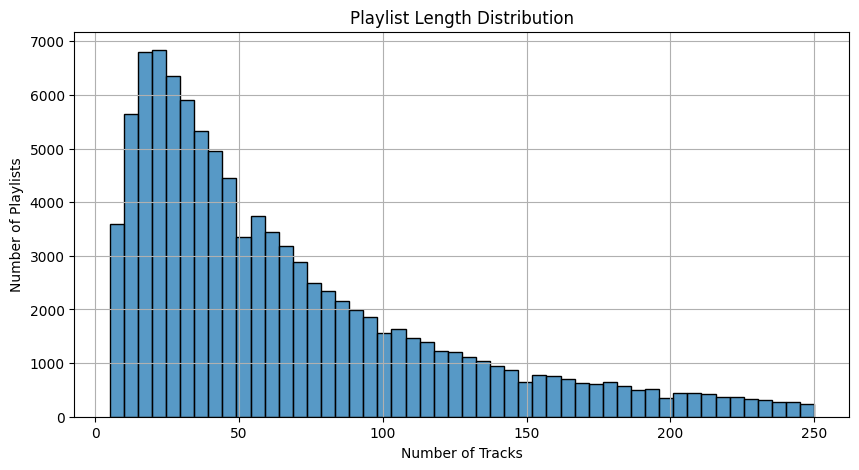

In [3]:
eda.plot_playlist_length_distribution(df)


/Users/vishnupb/Desktop/spotify_recommender/src/eda.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tracks.values, y=top_tracks.index, palette="viridis")


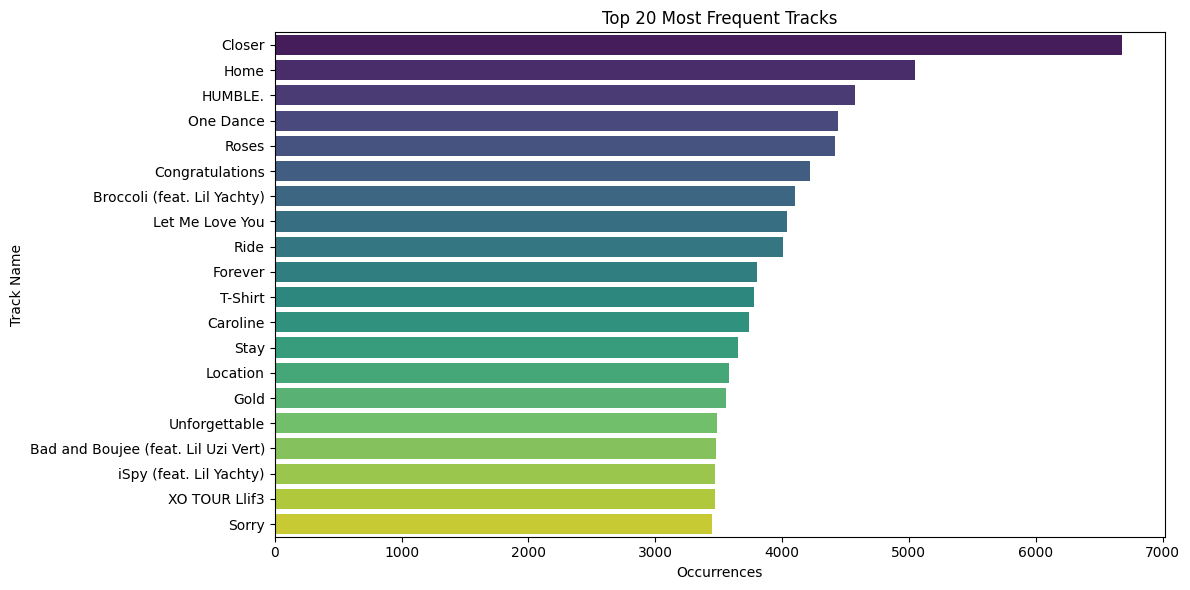

In [4]:
eda.plot_top_tracks(df, top_n=20)


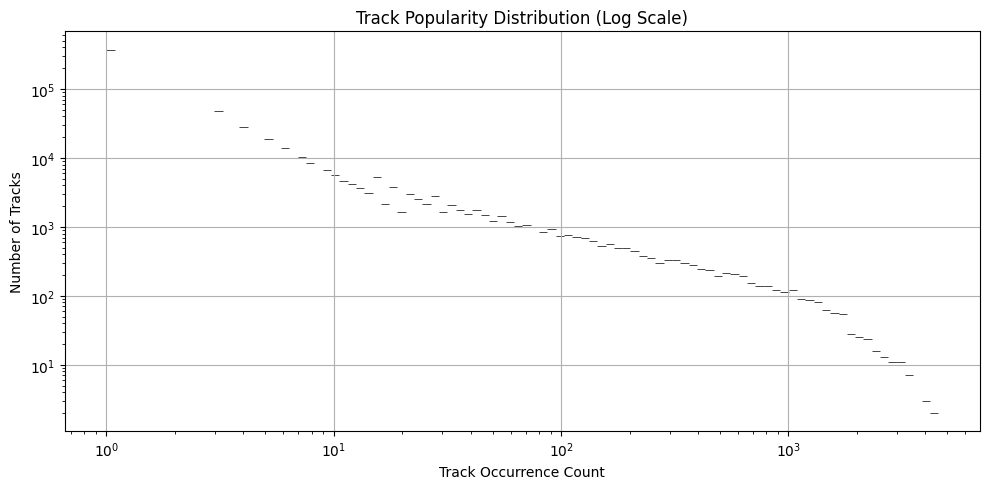

In [5]:
eda.plot_track_popularity_long_tail(df)


In [6]:
eda.get_cold_start_track_stats(df)


Cold-start tracks (appearing only once): 373016
Total unique tracks: 679889
Percentage of cold-start tracks: 54.86%


In [7]:
# Cell 1: Import and train
from cf_model import CFRecommender

cf = CFRecommender()
matrix = cf.prepare_matrix(df)
cf.train()


/opt/anaconda3/lib/python3.12/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


🔄 Preparing user-item matrix...
Training collaborative filtering model...


  0%|          | 0/20 [00:00<?, ?it/s]

In [8]:
example_pid = df['playlist_id'].sample(1).iloc[0]
print("🎧 Recommendations for Playlist ID:", example_pid)

recommended_tracks = cf.recommend_tracks(example_pid, N=10)
print("Recommended Track URIs:")
print(recommended_tracks)


🎧 Recommendations for Playlist ID: 148639
Recommended Track URIs:
['spotify:track:6RsWqX8zABZLhZydXxEFOm', 'spotify:track:0UaMYEvWZi0ZqiDOoHU3YI']


In [9]:
 # Save the processed playlist-track mapping
df.to_pickle('../data/processed_playlists.pkl')  # ✅ efficient format

# Optionally also save as CSV
# df.to_csv('../data/processed_playlists.csv', index=False)


In [10]:
# ✅ Extract unique tracks
df_tracks = df[['track_uri', 'track_name', 'artist_name', 'album_name']].drop_duplicates()

# Optionally add genres/duration/other features here

# Save to JSON Lines format
df_tracks.to_json('../data/tracks.json', orient='records', lines=True)
df_tracks.to_pickle('../data/processed_tracks.pkl')


In [10]:
import pickle
import os

# 💾 Save the trained CF model
cf_model_path = '../data/models/cf_model.pkl'
os.makedirs(os.path.dirname(cf_model_path), exist_ok=True)

with open(cf_model_path, 'wb') as f:
    pickle.dump(cf, f)

print(f"✅ CF model saved to: {cf_model_path}")


✅ CF model saved to: ../data/models/cf_model.pkl
